# Facial keypoint detection
The following notebook gives the solution for Kaggle project

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle



In [2]:
df_train = pd.read_csv("./data/training.csv")
df_test = pd.read_csv("./data/test.csv")


In [3]:
display(df_train.head())


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [4]:
df_train.columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y', 'Image'],
      dtype='str')

In [5]:
np.sqrt(np.fromstring(df_train["Image"][8], sep=" ").shape[0])

np.float64(96.0)

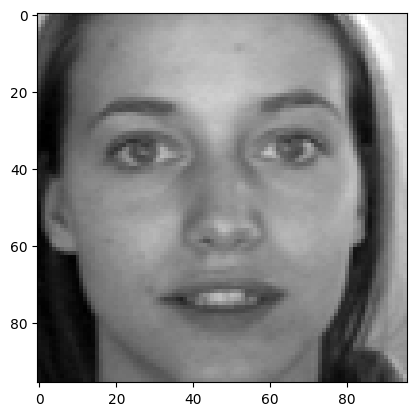

In [6]:
plt.imshow(np.fromstring(df_train["Image"][8], sep=" ").reshape(96, 96), cmap="gray")

In [21]:

FEATURE_COLORS = {
    "eye": "red",
    "eyebrow": "blue",
    "nose": "green",
    "mouth": "yellow"
}


def get_face_with_keypoints(df, image_index):
    image = np.fromstring(df["Image"][image_index], sep=" ").reshape(96, 96)

    keypoints = df.iloc[image_index, :-1].values.astype("float")
    keypoints = keypoints.reshape(-1, 2)

    return image, keypoints


def show_face_with_keypoints(df, image_index):
    image, keypoints = get_face_with_keypoints(df, image_index)

    # Column names except Image
    columns = df.columns[:-1]

    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap="gray")

    for i in range(0, len(columns), 2):

        x_name = columns[i]
        y_name = columns[i + 1]

        x, y = keypoints[i // 2]

        if np.isnan(x) or np.isnan(y):
            continue

        # Select color based on feature name
        if "eye" in x_name:
            color = FEATURE_COLORS["eye"]
        elif "eyebrow" in x_name:
            color = FEATURE_COLORS["eyebrow"]
        elif "nose" in x_name:
            color = FEATURE_COLORS["nose"]
        elif "mouth" in x_name:
            color = FEATURE_COLORS["mouth"]
        else:
            color = "white"

        # Draw point
        plt.scatter(x, y, color=color, s=10)

        # Add label
        label = x_name.replace("_x", "")
        plt.text(
            x + 1,
            y + 1,
            label,
            color=color,
            fontsize=7
        )

    plt.title(f"Face Keypoints - Image {image_index}")
    plt.axis("off")
    plt.show()

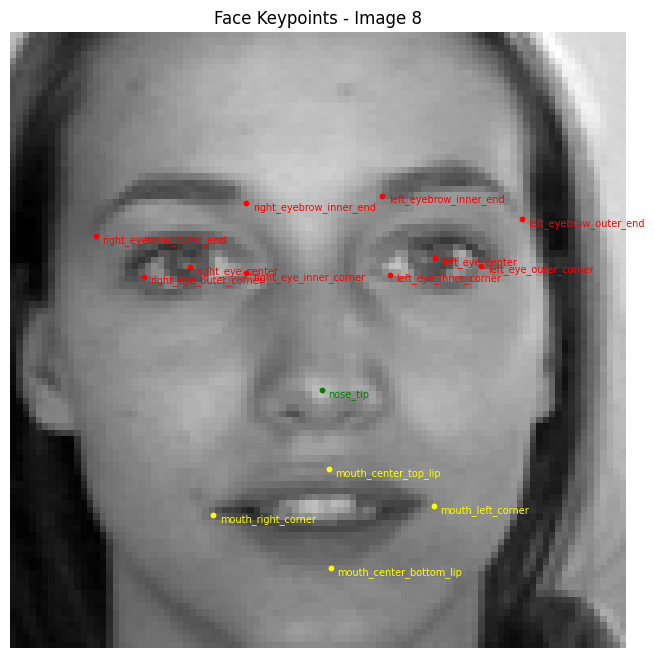

In [22]:
show_face_with_keypoints(df_train, 8)

## Image Preprocessing

In [24]:
len(df_train)

7049

In [25]:
df_train.isnull().sum()

left_eye_center_x              10
left_eye_center_y              10
right_eye_center_x             13
right_eye_center_y             13
left_eye_inner_corner_x      4778
left_eye_inner_corner_y      4778
left_eye_outer_corner_x      4782
left_eye_outer_corner_y      4782
right_eye_inner_corner_x     4781
right_eye_inner_corner_y     4781
right_eye_outer_corner_x     4781
right_eye_outer_corner_y     4781
left_eyebrow_inner_end_x     4779
left_eyebrow_inner_end_y     4779
left_eyebrow_outer_end_x     4824
left_eyebrow_outer_end_y     4824
right_eyebrow_inner_end_x    4779
right_eyebrow_inner_end_y    4779
right_eyebrow_outer_end_x    4813
right_eyebrow_outer_end_y    4813
nose_tip_x                      0
nose_tip_y                      0
mouth_left_corner_x          4780
mouth_left_corner_y          4780
mouth_right_corner_x         4779
mouth_right_corner_y         4779
mouth_center_top_lip_x       4774
mouth_center_top_lip_y       4774
mouth_center_bottom_lip_x      33
mouth_center_b